# 1. The use of device cuda or cpu in Pytorch

If possible, we want to use CUDA instead of the CPU because a GPU can perform many calculations **in parallel**.

We don't use CUDA all the time. For small programs and simple calculations, the CPU can be faster than the GPU. This is because moving data between the CPU and GPU takes time, and for small calculations this transfer time can be larger than the time saved by using the GPU.

For machine vision, there are often many calculations and large amounts of data. Neural networks, for example, perform many matrix and tensor calculations. These calculations can be performed very efficiently in parallel on a GPU. That is why GPUs are often used for machine vision and deep learning.

## Checking if CUDA is available
To check whether PyTorch can use CUDA, we can use:

In [1]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using {device} device")

Using cuda device


If the output is cuda, PyTorch is able to use an NVIDIA GPU through CUDA. If the output is cpu, PyTorch will use the CPU instead.

## Moving the model to GPU
When a model is created, it is normally stored on the CPU. If we want to use the GPU, we have to move the model to the selected device using ***.to(device)***:

In [5]:
from torchvision.models import resnet50, ResNet50_Weights
model =resnet50(weights=ResNet50_Weights.IMAGENET1K_V2) 
model = model.to(device)

## Moving the data to the GPU
It is also important that the model and the data are on the same device. 

For example, if the model is on the GPU but the input data is still on the CPU, PyTorch cannot directly perform the calculation. We therefore move the data to the same device as the model.

In [9]:
data = torch.randn((4,1))
print(f"Data before: {data.device}")

data = data.to(device)
print(f"Data after: {data.device}")

Data before: cpu
Data after: cuda:0


The most important thing to remember is that the model and the tensors used in the calculations must be on the same device.

# 2. How do we prepare our data for training with using DataLoaders

## Custom Dataset
https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html

Before we begin with loading in the dataset, we need a Custom Dataset class in PyTorch, because PyTorch needs a standard way to find, load, and prepare our images before giving them to the model.

A custom Dataset class must implement three functions: **\_\_init\_\_, \_\_len\_\_, and \_\_getitem\_\_**.

In [13]:
from torch.utils.data import Dataset
from PIL import Image

# Custom Dataset Class
class ImageDataset(Dataset):
    def __init__(self, image_paths, image_labels, transform=None):
        self.image_paths = image_paths
        self.image_labels = image_labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        #Load image
        image = Image.open(self.image_paths[idx]).convert('RGB')

        # Apply transformations if provided

        if self.transform:
            image = self.transform(image)

        # Get label
        label = self.image_labels[idx]
        return image, label

In [32]:
import os

# Define dataset path for the train and the test
dataset_path_train = "santa/train"
dataset_path_test = "santa/test"

# Define the labels
labels = ["santa", "not-a-santa"]

train_path = []
train_labels = []
test_path= []
test_labels = []

# For training
for label in labels:
    folder_path = os.path.join(dataset_path_train, label)
    
    # Get all image files in the folder
    for img_file in os.listdir(folder_path):
        train_path.append(os.path.join(folder_path, img_file))
        train_labels.append(label)

# For test
for label in labels:
    folder_path = os.path.join(dataset_path_test, label)
    
    # Get all image files in the folder
    for img_file in os.listdir(folder_path):
        test_path.append(os.path.join(folder_path, img_file))
        test_labels.append(label)

In [33]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Define transformations
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])
# Create the datasets
train_dataset = ImageDataset(train_path, train_labels, transform=transform)
test_dataset = ImageDataset(test_path, test_labels, transform=transform)

# Hyperparameters
batch_size = 32

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

print(train_loader)
print(test_loader)

# 3. How can we verify that the batch images and labels are correct?

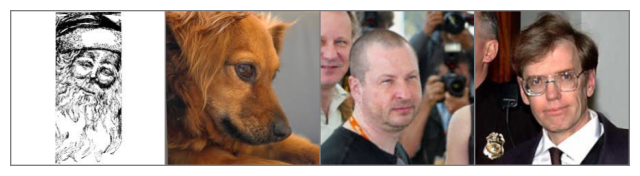

Labels:  santa, not-a-santa, not-a-santa, not-a-santa




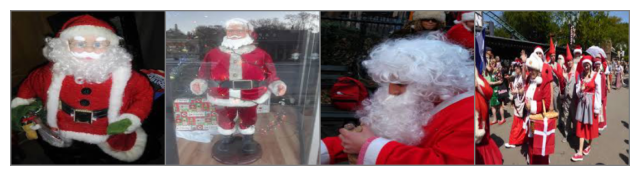

Labels:  santa, santa, santa, santa




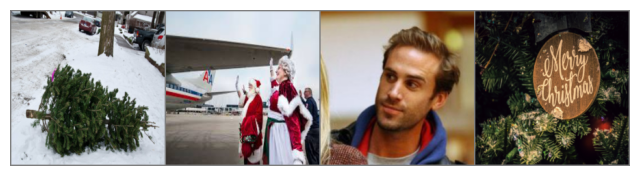

Labels:  not-a-santa, santa, not-a-santa, not-a-santa




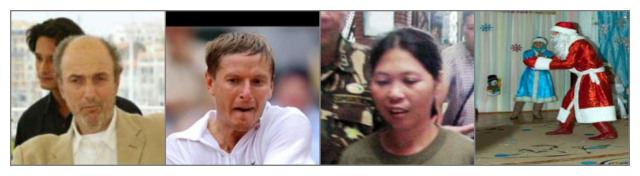

Labels:  not-a-santa, not-a-santa, not-a-santa, santa




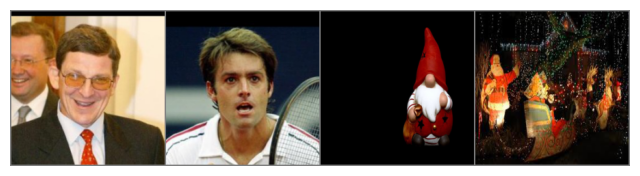

Labels:  not-a-santa, not-a-santa, santa, santa




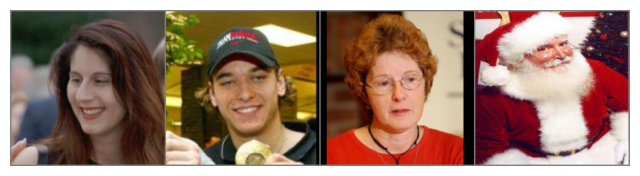

Labels:  not-a-santa, not-a-santa, not-a-santa, santa




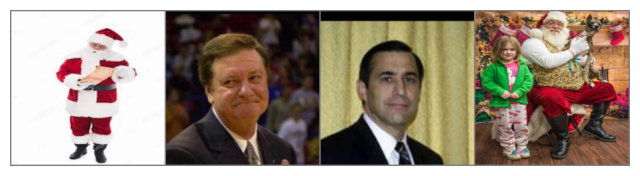

Labels:  santa, not-a-santa, not-a-santa, santa




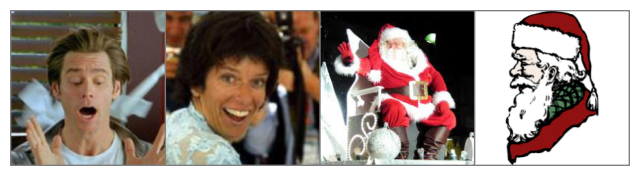

Labels:  not-a-santa, not-a-santa, santa, santa




In [34]:
import matplotlib.pyplot as plt
import torchvision
import numpy as np

## imshow method that displays images
def imshow(img, mean, std):
    # Unnormalize
    img = img * std[:, None, None] + mean[:, None, None]
    npimg = img.numpy()
    plt.figure(figsize=(8, 8))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()
    
# Get a batch of training data
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Define mean and std for unnormalization
mean = torch.tensor([0.5,0.5,0.5])
std = torch.tensor([0.5,0.5,0.5])

# Loop to display 4 images at a time
batch_size = 4

for i in range(0,len(images), batch_size):
    # Select a batch of 4 images and labels
    image_batch = images[i:i+batch_size]
    label_batch = labels[i:i+batch_size]

    # Show the images in the batch
    imshow(torchvision.utils.make_grid(image_batch), mean, std)

    # Print the labels for the current batch of images
    print('Labels: ', ', '.join(f'{label_batch[j]}' for j in range(len(label_batch))))
    print("\n")